<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/49_regression_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
X, y = make_regression(
    n_samples=500,
    n_features=5,
    noise=20,
    random_state=42
)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
models = {
    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            random_state=42
        )
}

In [6]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    results.append(
        [name, mae, rmse, r2]
    )

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R²"
    ]
)

results_df

,Model,MAE,RMSE,R²
0,Linear Regression,16.807665,20.622803,0.964964
1,Decision Tree,53.798484,63.552896,0.667269
2,Random Forest,30.266026,35.957390,0.893488


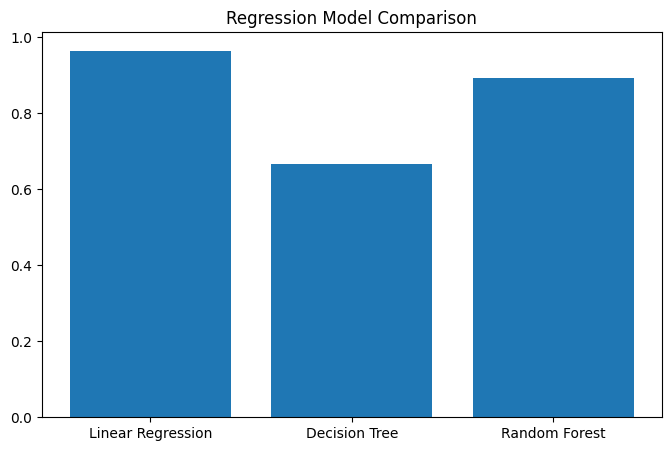

In [7]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["R²"]
)

plt.title(
    "Regression Model Comparison"
)

plt.show()

In [9]:
best_model = results_df.loc[
    results_df["R²"].idxmax()
]
print(best_model)

Model    Linear Regression
MAE              16.807665
RMSE             20.622803
R²                0.964964
Name: 0, dtype: object


## Conclusion

Multiple regression models were compared on the same dataset.

Observations:
- Different models achieved different error levels.
- Ensemble methods often produced stronger performance.
- R² Score helped compare explanatory power.
- Model comparison is important before selecting a final model.